#### 0) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

#### 1) Configurations

In [3]:
output_dir_str = r"C:/Users/Hassa/OneDrive - Loughborough University/current/Algorithmic Trading for Beginners/Backtesting Trading Strategies/Data/Processed"
output_dir = Path(output_dir_str)

tickers = ["AAPL", "META", "MSFT", "TSLA"]

# Load return historical series from Notebook 5
df_strat_returns = pd.read_parquet(output_dir / "strategy_returns_all.parquet")
df_port_returns = pd.read_parquet(output_dir / "portfolio_returns.parquet")

# Load Kelly Fractions from Notebook 4
with open(output_dir / "kelly_fractions.json", "r") as f:
    kelly_fractions = json.load(f)

print("Data assets successfully loaded for risk calibration.")

Data assets successfully loaded for risk calibration.


#### 2) ATR vs FIXED Stop 

In [4]:
stop_comparison = []

for ticker in tickers:
    for mode in ["FIXED", "ATR"]:
        filename = f"trades_{ticker}_{mode}_final_position_EMA.parquet"
        filepath = output_dir / filename
        
        if not filepath.exists():
            continue
            
        df_trades = pd.read_parquet(filepath)
        if df_trades.empty:
            continue
            
        returns = df_trades["Return %"]
        win_rate = (returns > 0).sum() / len(df_trades)
        avg_gain = returns[returns > 0].mean() if (returns > 0).any() else 0.0
        avg_loss = returns[returns <= 0].mean() if (returns <= 0).any() else 0.0
        payoff_ratio = avg_gain / abs(avg_loss) if avg_loss != 0 else 0.0
        
        stop_comparison.append({
            "Ticker": ticker,
            "Mode": mode,
            "Total Trades": len(df_trades),
            "Win Rate": win_rate,
            "Payoff Ratio": payoff_ratio,
            "Max Loss": returns.min(),
            "Avg Holding Days": df_trades["Holding Days"].mean()
        })

df_stops = pd.DataFrame(stop_comparison)
print("Stop Loss Regime Metric Contrast")
print(df_stops.to_string(index=False))

Stop Loss Regime Metric Contrast
Ticker  Mode  Total Trades  Win Rate  Payoff Ratio  Max Loss  Avg Holding Days
  AAPL FIXED           136  0.375000      5.339645 -0.082947         17.558824
  AAPL   ATR            98  0.377551      4.258801 -0.082947         24.275510
  META FIXED           131  0.396947      4.456279 -0.114615         15.526718
  META   ATR            91  0.362637      4.175266 -0.114615         22.263736
  MSFT FIXED           140  0.378571      3.706431 -0.090576         17.635714
  MSFT   ATR           105  0.380952      3.188475 -0.090576         23.409524
  TSLA FIXED           178  0.387640      7.281632 -0.075591         10.786517
  TSLA   ATR            97  0.360825      7.717046 -0.130293         19.608247


#### 3) Portfolio Volatility and Diversification Math

Portfolio Covariance and Structural Metrics
Realized Annualized Portfolio Volatility: 16.44%
Weighted Asset Component Volatility: 24.61%
Portfolio Diversification Ratio: 1.4970


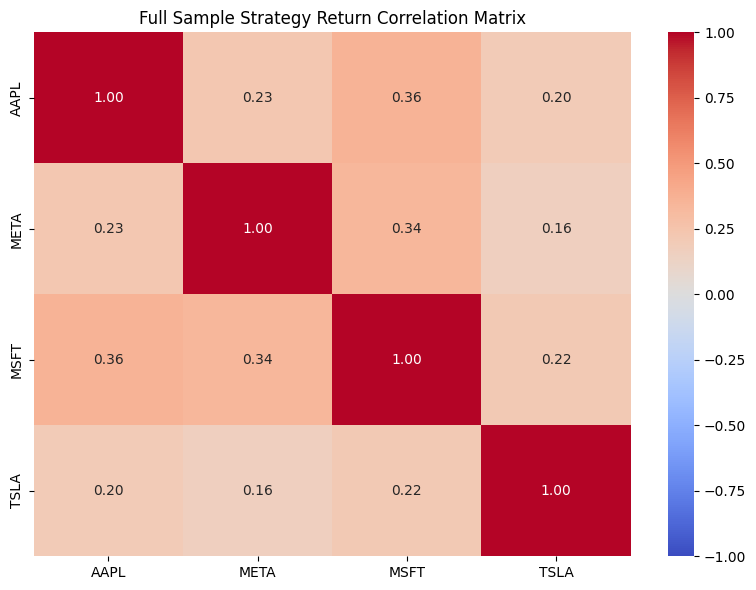

In [5]:
# Calculate full sample correlation and covariance
corr_matrix = df_strat_returns.corr()
cov_matrix = df_strat_returns.cov()

# Weights for equal weight portfolio (25% each)
weights = np.array([0.25] * len(tickers))

# Calculate individual asset volatilities (annualized)
asset_vols = df_strat_returns.std() * np.sqrt(252)

# Calculate realized portfolio volatility (annualized)
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
realized_portfolio_vol = np.sqrt(portfolio_variance) * np.sqrt(252)

# Diversification Ratio = Weighted Vol / Portfolio Vol
weighted_vol = np.sum(asset_vols * weights)
diversification_ratio = weighted_vol / realized_portfolio_vol

print("Portfolio Covariance and Structural Metrics")
print(f"Realized Annualized Portfolio Volatility: {realized_portfolio_vol:.2%}")
print(f"Weighted Asset Component Volatility: {weighted_vol:.2%}")
print(f"Portfolio Diversification Ratio: {diversification_ratio:.4f}")

# Display correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Full Sample Strategy Return Correlation Matrix")
plt.tight_layout()
plt.show()

#### 4) Volatility Targeted Sizing Engine

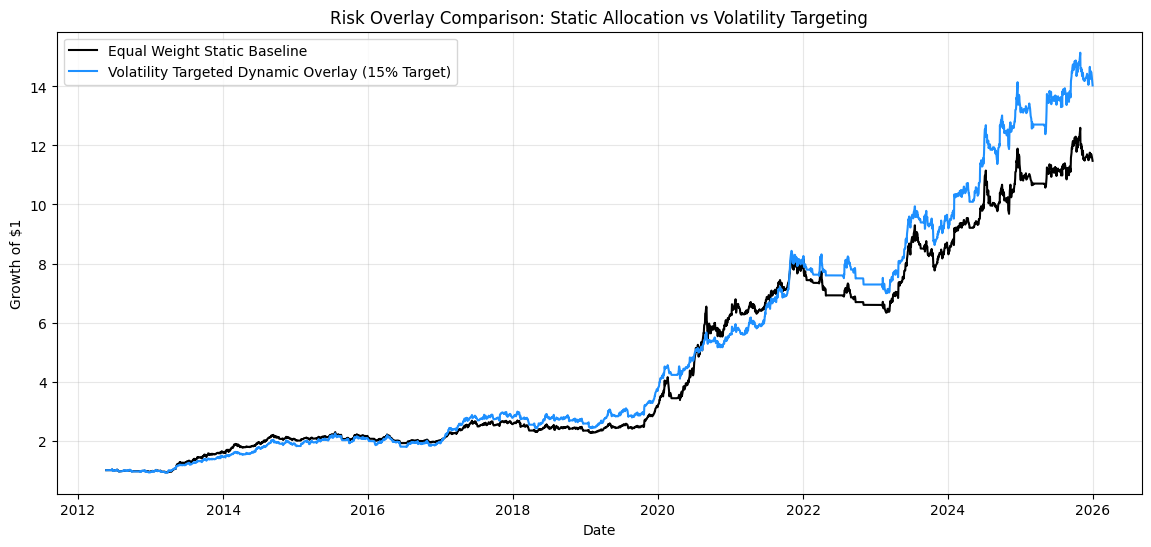

In [6]:
# target an annual volatility profile of 15 percent
TARGET_VOL = 0.15

# Calculate rolling 20 day realized volatility of the equal weight portfolio
# Annualize the daily rolling standard deviation
rolling_daily_vol = df_port_returns["Portfolio"].rolling(window=20).std()
rolling_ann_vol = rolling_daily_vol * np.sqrt(252)

# Sizing leverage is target vol divided by rolling vol (capped at 2x max leverage for safety)
vol_target_scale = (TARGET_VOL / rolling_ann_vol).shift(1).fillna(1.0)
vol_target_scale = np.clip(vol_target_scale, 0.1, 2.0)

# Generate vol targeted returns
df_port_returns["Vol_Target_Returns"] = df_port_returns["Portfolio"] * vol_target_scale

# Plot the equity curves
cum_equal_weight = (1 + df_port_returns["Portfolio"]).cumprod()
cum_vol_target = (1 + df_port_returns["Vol_Target_Returns"]).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cum_equal_weight.index, cum_equal_weight, label="Equal Weight Static Baseline", color="black")
plt.plot(cum_vol_target.index, cum_vol_target, label="Volatility Targeted Dynamic Overlay (15% Target)", color="dodgerblue")
plt.title("Risk Overlay Comparison: Static Allocation vs Volatility Targeting")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 5) Fractional Kelly Sizing

In [7]:
df_kelly_returns = pd.DataFrame(index=df_strat_returns.index)

for ticker in tickers:
    raw_kelly = kelly_fractions.get(ticker, 0.0)
    # Apply Half Kelly fraction for conservative buffer
    half_kelly = max(0.0, raw_kelly / 2.0)
    
    # Scale individual asset returns by half kelly multiplier
    df_kelly_returns[ticker] = df_strat_returns[ticker] * half_kelly

# Aggregate sized assets into custom portfolio assuming equal capital slices among active allocations
df_port_returns["Half_Kelly_Returns"] = df_kelly_returns.mean(axis=1)

cum_kelly = (1 + df_port_returns["Half_Kelly_Returns"]).cumprod()
print(f"Half Kelly allocation tracking run completed. Terminal Value: ${cum_kelly.iloc[-1]:.2f}")

Half Kelly allocation tracking run completed. Terminal Value: $1.37


#### 6) Time in Market Efficiency Martrix

In [9]:
efficiency_metrics = {}

for col in df_strat_returns.columns:
    series = df_strat_returns[col]
    
    # Time in market is defined as daily returns that do not equal zero
    time_in_market = (series != 0).sum() / len(series)
    
    # Calculate standard CAGR
    total_days = (series.index.max() - series.index.min()).days
    years = total_days / 365.25
    cum_return = (1 + series).prod()
    cagr = (cum_return ** (1 / years)) - 1 if cum_return > 0 else 0.0
    
    # Capital Efficiency = CAGR divided by Time in Market Percentage
    capital_efficiency = cagr / time_in_market if time_in_market > 0 else 0.0
    
    efficiency_metrics[col] = {
        "Time In Market %": time_in_market,
        "CAGR": cagr,
        "Capital Efficiency Metric": capital_efficiency
    }

df_efficiency = pd.DataFrame(efficiency_metrics).T
print("Asset Level Capital Efficiency Metrics")
print(df_efficiency.round(4))

Asset Level Capital Efficiency Metrics
      Time In Market %    CAGR  Capital Efficiency Metric
AAPL            0.5894  0.1365                     0.2316
META            0.6072  0.1264                     0.2082
MSFT            0.6648  0.0904                     0.1360
TSLA            0.5114  0.3522                     0.6887


#### 7) Consolidation and Output Export

In [10]:
summary_output = {
    "Portfolio_Realized_Vol": realized_portfolio_vol,
    "Portfolio_Diversification_Ratio": diversification_ratio,
    "Static_Portfolio_CAGR": ((1 + df_port_returns["Portfolio"].mean()) ** 252) - 1,
    "Vol_Target_Portfolio_CAGR": ((1 + df_port_returns["Vol_Target_Returns"].mean()) ** 252) - 1,
    "Half_Kelly_Portfolio_CAGR": ((1 + df_port_returns["Half_Kelly_Returns"].mean()) ** 252) - 1,
}

df_risk_summary = pd.DataFrame([summary_output])
df_risk_summary.to_parquet(output_dir / "risk_calibration_summary.parquet")

print("Risk Calibration Summary successfully saved to risk_calibration_summary.parquet")
print(df_risk_summary.T)

Risk Calibration Summary successfully saved to risk_calibration_summary.parquet
                                        0
Portfolio_Realized_Vol           0.164385
Portfolio_Diversification_Ratio  1.496995
Static_Portfolio_CAGR            0.213163
Vol_Target_Portfolio_CAGR        0.232134
Half_Kelly_Portfolio_CAGR        0.023892
